# **Correlation entree sortie du Transformer**

In [ ]:
import matplotlib
matplotlib.use('Agg')  # Backend non-interactif
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import glob
import numpy as np
import astropy.units as u
import random
import pandas as pd
import copy
import json
import numba
import pickle
import astropy.units as u

from tqdm.auto import tqdm
from textwrap import fill
from astropy.io import fits
from astropy.table import join
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.coordinates import search_around_sky
from astropy.coordinates import angular_separation
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from collections import Counter

from constantes import LIM_FLUX_CLUSTER, LIM_FLUX_AGN, SEARCH_RADIUS_CLUSTER, SEARCH_RADIUS_AGN, EXT_LIKE_C1, EXT_LIKE_C2, EXT_C1_C2, PNT_DET_ML_SPURIOUS, EXT_LIKE_SPURIOUS, WINDOW_SIZE_ARCMIN
from constantes import print_parameters

print_parameters()


/local/home/sh275430/mon_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


╭─────────────────────────────────────────────╮
│                  PARAMÈTRES                 │
├─────────────────────────────────────────────┤
│ LIM_FLUX_CLUSTER      : 1.00e-15 erg/cm²/s 
│ LIM_FLUX_AGN          : 1.00e-15 erg/cm²/s 
│ SEARCH_RADIUS_CLUSTER : 30.00    arcsec    
│ SEARCH_RADIUS_AGN     : 10.00    arcsec    
│ EXT_LIKE_C1           : 33       
│ EXT_LIKE_C2           : 15       
│ EXT_C1_C2             : 5        arcsec    
│ EXT_LIKE_C1_new       : 80       
│ EXT_LIKE_C2_new       : 35       
│ EXT_C1_C2_new         : 13       arcsec    
│ window_size           : 3.0      arcmin    
│ PNT_DET_ML_SPURIOUS   : 20       
│ EXT_LIKE_SPURIOUS     : 15       
│ NOMBRE_PHOTONS_MIN    : 100      photons   
╰─────────────────────────────────────────────╯


# **Chargement des données**

In [2]:
name_dir = 'Simulation2'
X_train = np.loadtxt(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/X_train.txt', dtype=int)
X_test  = np.loadtxt(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/X_test.txt', dtype=int)

In [3]:
with open(f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_Xamin.json", 'r') as f:
    global_stats_Xamin = json.load(f)
with open(f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_input_clusters.json", 'r') as f:
    global_stats_clusters = json.load(f)
with open(f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/global_stats_input_AGN.json", 'r') as f:
    global_stats_AGN = json.load(f)

In [4]:
with open(f"/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/constantes_du_modele.json", 'r') as f:
    config = json.load(f)

# Extraction des valeurs
MAX_SOURCES  = config["MAX_SOURCES"]
MAX_CLUSTERS = config["MAX_CLUSTERS"]
MAX_AGN = config["MAX_AGN"]
VOCAB_SIZE   = config["VOCAB_SIZE"]
PAD_TOKEN    = config["PAD_TOKEN"]
SEP_TOKEN    = config["SEP_TOKEN"]
CLS_TOKEN    = config["CLS_TOKEN"]

print("┌───────────────────────────────┐")
print("│  CONFIGURATION DU MODÈLE      │")
print("├───────────────────────────────┤")
for key, value in config.items():
    print(f"│ {key.ljust(15)}: {str(value).rjust(10)}   │")
print("└───────────────────────────────┘")

┌───────────────────────────────┐
│  CONFIGURATION DU MODÈLE      │
├───────────────────────────────┤
│ VOCAB_SIZE     :       1029   │
│ PAD_TOKEN      :       1024   │
│ SEP_TOKEN      :       1025   │
│ CLS_TOKEN      :       1026   │
│ SEP_AMAS       :       1027   │
│ SEP_AGN        :       1028   │
│ NOMBRE_TOKENS_SPECIAUX:          5   │
│ MAX_SOURCES    :          7   │
│ MAX_CLUSTERS   :          2   │
│ MAX_AGN        :          8   │
└───────────────────────────────┘


In [5]:
with open(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/generated_seq_by_imperator_test_0-5000.pkl', 'rb') as f:
    seq_gen_0_5000 = pickle.load(f)
with open(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/generated_seq_by_imperator_test_5001-10000.pkl', 'rb') as f:
    seq_gen_5001_10000 = pickle.load(f)
#with open(f'/local/home/sh275430/Documents/TransformerSurFenestrons/results/{name_dir}/generated_seq_by_imperator_test_10001-15000.pkl', 'rb') as f:
#    seq_gen_10001_15000 = pickle.load(f)

seq_gen_0_5000      = np.array(seq_gen_0_5000)
seq_gen_5001_10000  = np.array(seq_gen_5001_10000)
#seq_gen_10001_15000 = np.array(seq_gen_10001_15000)

print(seq_gen_0_5000.shape)
print(seq_gen_5001_10000.shape)
#print(seq_gen_10001_15000.shape)

#seq_gen = np.vstack((seq_gen_0_5000, seq_gen_5001_10000, seq_gen_10001_15000))
seq_gen = np.vstack((seq_gen_0_5000, seq_gen_5001_10000))

(5001, 99)
(5000, 99)


In [6]:
print(X_test[0])
print(seq_gen[0])

[1026  645  765  518  531  444  448  303  511  511  367  359  691  713
  678  610  443  463  375  674  613  432  424 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1027  558  599 1024 1024 1028
  504  514  678  610 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1025]
[1026  645  765  518  531  444  448  303  511  511  367  359  691  713
  678  610  443  463  375  674  613  432  424 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024 1024 1024 1024 1024 1024 1024 1027  507  515 1024 1024 1028
  507  511  507  511 1024 1024 1024 1024 1024 1024 1024 1024

# **Variables utilisées**

In [7]:
SELECTED_COLUMNS_Xamin    = ['EXT_LIKE', 'EXT', 'EXT_RA', 'EXT_DEC', 'EXT_RATE_MOS', 'EXT_RATE_PN', 'PNT_DET_ML', 'PNT_RA', 'PNT_DEC', 'PNT_RATE_MOS', 'PNT_RATE_PN']
SELECTED_COLUMNS_clusters = ['R.A.', 'Dec']
SELECTED_COLUMNS_AGN      = ['ra_mag_gal', 'dec_mag_gal']

use_log_scale_Xamin    = [True, True, False, False, True, True, True, False, False, True, True]
use_log_scale_clusters = [False, False]
use_log_scale_AGN      = [False, False]

columns_dict_Xamin = {column: index for index, column in enumerate(SELECTED_COLUMNS_Xamin)}
columns_dict_clusters = {column: index for index, column in enumerate(SELECTED_COLUMNS_clusters)}
columns_dict_AGN = {column: index for index, column in enumerate(SELECTED_COLUMNS_AGN)}

# **Fonction de discretisation inverse**

In [ ]:
def discretized_to_real(values, col, global_stats, columns_dict, log_scale_flag, n_bins):
    """
    Converts discretized values (e.g., from binning into n_bins) back to their original real-world scale,
    using global statistics for the specified column.

    Parameters:
        values (list or array): Discretized values to convert.
        col (str): Name of the column these values belong to.
        global_stats (dict): Dictionary containing global statistics for each column 
                             (e.g., min, max, log_min).
        columns_dict (dict): Maps column names to their corresponding index or identifier.
        log_scale_flag (list or array of bool): Indicates whether each column uses a logarithmic scale.
        n_bins (int): Total number of bins used for discretization.

    Returns:
        np.array: The values converted back to their real (linear or logarithmic) scale.
    """
    if col not in global_stats:
        return values

    # Conversion en valeurs normalisées [0, 1]
    norm_vals = np.asarray(values) / (n_bins - 1)
    col_stats = global_stats[col]

    if log_scale_flag[columns_dict[col]]:
        log_range = np.log10(col_stats['max']) - col_stats['log_min']
        log_vals = col_stats['log_min'] + norm_vals * log_range
        return 10**log_vals
    else:
        return col_stats['min'] + norm_vals * (col_stats['max'] - col_stats['min'])

# **Extraction des catalogues d'entrée ou sortie des amas ou AGN**

liste_ra_dec[::2]  → Prend tous les éléments d'indice pair (ra1, ra2, ra3, ...).

liste_ra_dec[1::2] → Prend tous les éléments d'indice impair (dec1, dec2, dec3, ...)

zip()              → Combine les deux slices pour itérer par paires.

In [ ]:
def ExtractionOutput(table_seq, global_stats, columns_dict, use_log_scale, type):
    """
    Extracts and converts RA and DEC values from a tokenized sequence into real-world coordinates,
    based on the specified object type ('AMAS' for clusters or 'AGN' for active galactic nuclei).

    Parameters:
        table_seq (np.array): 2D array representing a batch of tokenized input sequences.
        global_stats (dict): Dictionary containing global statistics (min, max, log_min, etc.) for each column.
        columns_dict (dict): Maps column names to their corresponding index in log_scale_flag.
        use_log_scale (list or array of bool): Flags indicating whether each column uses a logarithmic scale.
        type (str): Type of object to extract, either 'AMAS' (clusters) or 'AGN'.

    Returns:
        filtered_table (np.array): Integer array of shape (n_valid_entries, 3) containing [window_index, RA, DEC] 
                                   with RA and DEC still in discretized form.
        table_in_degrees (np.array): Float array of same shape as filtered_table, but with RA and DEC converted 
                                     to real-world degree coordinates.
    """
    
    if type == 'AMAS':
        indice_debut = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + 2 # +2 pour les tokens de debut de sequence et celui du catalogue d'amas
        indice_fin   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS +1 # +1 pour marquer le debut du catalogue d'amas
        n_rows = len(table_seq) * MAX_CLUSTERS  # Nombre de lignes du nouveau tableau
        keys = {'RA' : 'R.A.', 'DEC' : 'Dec'}
        
    elif type == 'AGN':
        indice_debut = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS + 3  # +2 pour les tokens de debut de sequence et celui du catalogue d'amas ET celui AGN
        indice_fin   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS + len(SELECTED_COLUMNS_AGN) * MAX_AGN +1
        n_rows = len(table_seq) * MAX_AGN  # Nombre de lignes du nouveau tableau
        keys = {'RA' : 'ra_mag_gal', 'DEC' :'dec_mag_gal'}


    liste_ra_dec = table_seq[:,indice_debut: indice_fin + 1] #+1 a cause de la convention en python

    # Création du tableau
    table = np.zeros((n_rows, 3), dtype=np.int64)  # Initialisation à 0 partout
    table[:, 1:] = PAD_TOKEN  # RA et DEC remplis avec PAD_TOKEN
    table_cols = {'num_window': 0, 'RA': 1, 'DEC': 2} # Nommage des colonnes

    row_index = 0
    for i, win in enumerate(liste_ra_dec):
        for ra, dec in zip(win[::2], win[1::2]):
            table[row_index, table_cols['num_window']] = i
            table[row_index, table_cols['RA']] = ra
            table[row_index, table_cols['DEC']] = dec
            row_index += 1

    mask = np.logical_and(table[:, 1] != PAD_TOKEN, table[:, 2] != PAD_TOKEN)
    filtered_table = table[mask]
    
    table_in_degrees = filtered_table.astype(np.float64)

    table_in_degrees[:, table_cols['RA']]  = discretized_to_real(filtered_table[:, table_cols['RA']], keys['RA'], global_stats, columns_dict, use_log_scale, n_bins = int(VOCAB_SIZE-3))
    table_in_degrees[:, table_cols['DEC']] = discretized_to_real(filtered_table[:, table_cols['DEC']], keys['DEC'], global_stats, columns_dict, use_log_scale, n_bins = int(VOCAB_SIZE-3))

    return filtered_table, table_in_degrees


In [10]:
table_AMAS, table_in_degrees_AMAS = ExtractionOutput(X_test, global_stats_clusters, columns_dict_clusters, use_log_scale_clusters, 'AMAS')
table_AGN, table_in_degrees_AGN   = ExtractionOutput(X_test, global_stats_AGN, columns_dict_AGN, use_log_scale_AGN, 'AGN')

In [11]:
gen_AMAS, gen_in_degrees_AMAS = ExtractionOutput(seq_gen, global_stats_clusters, columns_dict_clusters, use_log_scale_clusters, 'AMAS')
gen_AGN, gen_in_degrees_AGN   = ExtractionOutput(seq_gen, global_stats_AGN, columns_dict_AGN, use_log_scale_AGN, 'AGN')

# **Petit test**

In [12]:
num_fenetre = random.randint(0, 100)

#print("\n\033[1mSequence complete:\033[0m")
#print(X_test[num_fenetre])

indice_debut_AMAS = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + 2
indice_fin_AMAS   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS +1

print("\n\033[1mCatalogue AMAS:\033[0m")
print(X_test[num_fenetre,indice_debut_AMAS:indice_fin_AMAS+1])

indice_debut_AGN = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS + 3 
indice_fin_AGN   = len(SELECTED_COLUMNS_Xamin) * MAX_SOURCES + len(SELECTED_COLUMNS_clusters) * MAX_CLUSTERS + len(SELECTED_COLUMNS_AGN) * MAX_AGN + 2

print("\n\033[1mCatalogue AGN:\033[0m")
print(X_test[num_fenetre,indice_debut_AGN:indice_fin_AGN+1])

print("\n\033[1mCatalogue AMAS extrait par la fonction:\033[0m")
print(table_AMAS[table_AMAS[:, 0] == num_fenetre])

print("\n\033[1mCatalogue AGN extrait par la fonction:\033[0m")
print(table_AGN[table_AGN[:, 0] == num_fenetre])


Catalogue AMAS:
[ 512  519 1024 1024]

Catalogue AGN:
[ 512  518  510  499  594  421 1024 1024 1024 1024 1024 1024 1024 1024
 1024 1024]

Catalogue AMAS extrait par la fonction:
[[ 17 512 519]]

Catalogue AGN extrait par la fonction:
[[ 17 512 518]
 [ 17 510 499]
 [ 17 594 421]]


In [13]:
print("\n\033[1mCatalogue AMAS extrait par la fonction:\033[0m")
print(table_in_degrees_AMAS[table_in_degrees_AMAS[:, 0] == num_fenetre])

print("\n\033[1mCatalogue AGN extrait par la fonction:\033[0m")
print(table_in_degrees_AGN[table_in_degrees_AGN[:, 0] == num_fenetre])


Catalogue AMAS extrait par la fonction:
[[ 1.70000000e+01 -2.86876718e-05  3.50995363e-04]]

Catalogue AGN extrait par la fonction:
[[ 1.70000000e+01 -3.51934168e-05  3.44250015e-04]
 [ 1.70000000e+01 -1.69753954e-04 -9.33348526e-04]
 [ 1.70000000e+01  5.48178861e-03 -6.17822675e-03]]


# **Second petit test**

In [599]:
num_fenetre = random.randint(0, 100)

print("\n\033[1mCatalogue AMAS et AGN initial:\033[0m")
print(table_AMAS[table_AMAS[:, 0] == num_fenetre])
print(table_AGN[table_AGN[:, 0] == num_fenetre])

print("\n\033[1mCatalogue AMAS et AGN predit par le Transformer:\033[0m")
print(gen_AMAS[gen_AMAS[:, 0] == num_fenetre])
print(gen_AGN[gen_AGN[:, 0] == num_fenetre])


Catalogue AMAS et AGN initial:
[[  2 507 506]]
[[  2 515 519]
 [  2 678 616]
 [  2 331 596]
 [  2 752 862]]

Catalogue AMAS et AGN predit par le Transformer:
[[  2 507 507]]
[[  2 507 507]
 [  2 507 507]
 [  2 507 507]
 [  2 507 507]]


# **Fonction de corrélation générale entre deux catalogues**

In [ ]:
def Compte_rapidement_avec_correlation_par_fenetre(table_input, table_output, rayon_corr_arcmin, table_cols = {'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Quickly computes the spatial correlation between two catalogs of the same type, 
    processed separately per window. For each window, it counts how many sources 
    in the reference catalog have at least one matching source in the predicted catalog 
    within a given angular radius.

    Args:
        table_input (np.ndarray): Reference catalog with columns ['num_window', 'RA', 'DEC'].
        table_output (np.ndarray): Predicted catalog, in the same format as table_input.
        rayon_corr_arcmin (float): Correlation radius in arcminutes.
        table_cols (dict): Dictionary mapping column names to indices 
                        (e.g., {'num_window': 0, 'RA': 1, 'DEC': 2}).

    Returns:
        dict: A dictionary where each key is a window index (int), and each value is another dict with:
            - 'nb_corr' (int): Number of sources in the input catalog that matched at least one in the output.
            - 'fraction' (float): Fraction of matched sources over the total number of sources in the input catalog.
    """

    resultats = {}

    rayon_corr_deg = rayon_corr_arcmin / 60

    fenetres = np.unique(table_input[:, table_cols['num_window']])

    for fen in fenetres:
        # Extraire les objets de la fenêtre actuelle
        input  = table_input[table_input[:, table_cols['num_window']] == fen]
        output = table_output[table_output[:, table_cols['num_window']] == fen]

        if len(input) == 0:
            continue

        coords_input = SkyCoord(ra=input[:, table_cols['RA']] * u.deg,
                              dec=input[:, table_cols['DEC']] * u.deg)
        coords_output = SkyCoord(ra=output[:, table_cols['RA']] * u.deg,
                               dec=output[:, table_cols['DEC']] * u.deg)

        nb_corr = 0
        for coord in coords_input:
            sep = coord.separation(coords_output)
            if np.any(sep.degree <= rayon_corr_deg):
                nb_corr += 1

        resultats[int(fen)] = {
            'nb_corr': nb_corr,
            'fraction': nb_corr / len(coords_input)
        }

    return resultats


In [ ]:
def Compte_rapidement_avec_correlation_par_fenetre(table_input, table_output, rayon_corr_arcmin, table_cols = {'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Computes the spatial correlation between two catalogs (e.g., predicted vs. reference),
    window by window, using celestial coordinates projected with a common offset frame.
    It counts how many sources in the input catalog have at least one match in the output
    catalog within a given angular radius.

    Args:
        table_input (np.ndarray): Reference catalog, expected to contain columns for window index,
                                right ascension (RA), and declination (DEC).
        table_output (np.ndarray): Predicted catalog, with the same structure as table_input.
        rayon_corr_arcmin (float): Correlation radius in arcminutes; used to determine matches.
        table_cols (dict): Dictionary mapping column names to their indices in the input arrays,
                        e.g., {'num_window': 0, 'RA': 1, 'DEC': 2}.

    Returns:
        dict: Dictionary with one entry per window, where each value is another dictionary containing:
            - 'nb_corr' (int): Number of sources in the input catalog that had at least one
                            corresponding source in the output catalog within the given radius.
            - 'fraction' (float): Ratio of matched sources over total sources in the input catalog
                                for that window.
    """


    resultats = {}

    rayon_corr_deg = rayon_corr_arcmin / 60

    fenetres = np.unique(table_input[:, table_cols['num_window']])

    # Centre fictif pour la projection (sur la sphère céleste)
    centre_fictif = SkyCoord(ra=180 * u.deg, dec=0 * u.deg, frame='icrs')
    offset_frame = SkyOffsetFrame(origin=centre_fictif)

    for fen in fenetres:
        input_fen  = table_input[table_input[:, table_cols['num_window']] == fen]
        output_fen = table_output[table_output[:, table_cols['num_window']] == fen]

        if len(input_fen) == 0:
            continue

        # Coordonnées relatives transformées en coordonnées absolues sur la sphère
        ra_input_rel = input_fen[:, table_cols['RA']] * u.deg
        dec_input_rel = input_fen[:, table_cols['DEC']] * u.deg
        ra_output_rel = output_fen[:, table_cols['RA']] * u.deg
        dec_output_rel = output_fen[:, table_cols['DEC']] * u.deg

        coords_input = SkyCoord(lon=ra_input_rel, lat=dec_input_rel, frame=offset_frame).transform_to('icrs')
        coords_output = SkyCoord(lon=ra_output_rel, lat=dec_output_rel, frame=offset_frame).transform_to('icrs')

        nb_corr = 0
        for coord in coords_input:
            sep = coord.separation(coords_output)
            if np.any(sep.degree <= rayon_corr_deg):
                nb_corr += 1

        resultats[int(fen)] = {
            'nb_corr': nb_corr,
            'fraction': nb_corr / len(coords_input)
        }

    return resultats


In [17]:
resultats = Compte_rapidement_avec_correlation_par_fenetre(table_in_degrees_AMAS, gen_in_degrees_AMAS, rayon_corr_arcmin=10, table_cols={'num_window': 0, 'RA': 1, 'DEC': 2})

for fen, stats in resultats.items():
    print(f"Fenêtre {fen} → {stats['nb_corr']} correspondances ({stats['fraction']:.1%})")


Fenêtre 0 → 1 correspondances (100.0%)
Fenêtre 1 → 1 correspondances (100.0%)
Fenêtre 2 → 1 correspondances (100.0%)
Fenêtre 3 → 1 correspondances (100.0%)
Fenêtre 4 → 1 correspondances (100.0%)
Fenêtre 5 → 1 correspondances (100.0%)
Fenêtre 6 → 1 correspondances (100.0%)
Fenêtre 7 → 1 correspondances (100.0%)
Fenêtre 8 → 1 correspondances (100.0%)
Fenêtre 9 → 1 correspondances (100.0%)
Fenêtre 10 → 1 correspondances (100.0%)
Fenêtre 11 → 1 correspondances (100.0%)
Fenêtre 12 → 1 correspondances (100.0%)
Fenêtre 13 → 1 correspondances (100.0%)
Fenêtre 14 → 1 correspondances (100.0%)
Fenêtre 15 → 1 correspondances (100.0%)
Fenêtre 16 → 1 correspondances (100.0%)
Fenêtre 17 → 1 correspondances (100.0%)
Fenêtre 18 → 1 correspondances (100.0%)
Fenêtre 19 → 1 correspondances (100.0%)
Fenêtre 20 → 2 correspondances (100.0%)
Fenêtre 21 → 1 correspondances (100.0%)
Fenêtre 22 → 1 correspondances (100.0%)
Fenêtre 23 → 1 correspondances (100.0%)
Fenêtre 24 → 1 correspondances (100.0%)
Fenêtre 25

In [ ]:
def correlation_par_fenetre(table_input, table_output, rayon_corr_arcsec, table_cols={'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Computes the spatial correlation between two catalogs window by window, and also 
    returns the matched pairs of coordinates. RA and DEC are assumed to be relative 
    positions (in degrees) centered at (0, 0), which are projected onto the celestial sphere.

    Args:
        table_input (np.ndarray): Reference catalog, with columns for window index, RA, and DEC.
        table_output (np.ndarray): Predicted catalog, same format as table_input.
        rayon_corr_arcsec (float): Matching radius in arcseconds.
        table_cols (dict): Dictionary mapping column names to indices 
                        (e.g., {'num_window': 0, 'RA': 1, 'DEC': 2}).

    Returns:
        resultats (dict): Dictionary where each key is a window index, and each value is a dict with:
            - 'nb_corr' (int): Number of input sources matched within the correlation radius.
            - 'fraction' (float): Proportion of matched sources over the total in that window.
        paires_trouvees (np.ndarray): Array of matched pairs with columns:
            ['num_window', 'RA_input', 'DEC_input', 'RA_output', 'DEC_output'].
    """

    resultats = {}
    matched_rows = []

    rayon_corr_deg = rayon_corr_arcsec / 3600
    fenetres = np.unique(table_input[:, table_cols['num_window']])

    # Centre fictif pour la projection (sur la sphère céleste)
    centre_fictif = SkyCoord(ra=180 * u.deg, dec=0 * u.deg, frame='icrs')
    offset_frame = SkyOffsetFrame(origin=centre_fictif)

    for fen in fenetres:
        input_fen = table_input[table_input[:, table_cols['num_window']] == fen]
        output_fen = table_output[table_output[:, table_cols['num_window']] == fen]

        if len(input_fen) == 0 or len(output_fen) == 0:
            continue

        # Convertir coordonnées relatives -> coordonnées absolues (projeter sur la sphère)
        ra_input_rel   = input_fen[:, table_cols['RA']] * u.deg
        dec_input_rel  = input_fen[:, table_cols['DEC']] * u.deg
        ra_output_rel  = output_fen[:, table_cols['RA']] * u.deg
        dec_output_rel = output_fen[:, table_cols['DEC']] * u.deg

        coords_input_proj  = SkyCoord(lon=ra_input_rel, lat=dec_input_rel, frame=offset_frame).transform_to('icrs')
        coords_output_proj = SkyCoord(lon=ra_output_rel, lat=dec_output_rel, frame=offset_frame).transform_to('icrs')

        nb_corr = 0
        for i, coord in enumerate(coords_input_proj):
            sep = coord.separation(coords_output_proj)
            min_sep_idx = np.argmin(sep)

            if sep[min_sep_idx].degree <= rayon_corr_deg:
                nb_corr += 1
                matched_rows.append([
                    int(fen),
                    input_fen[i, table_cols['RA']],
                    input_fen[i, table_cols['DEC']],
                    output_fen[min_sep_idx, table_cols['RA']],
                    output_fen[min_sep_idx, table_cols['DEC']]
                ])

        resultats[int(fen)] = {
            'nb_corr': nb_corr,
            'fraction': nb_corr / len(coords_input_proj)
        }

    paires_trouvees = np.array(matched_rows)
    return resultats, paires_trouvees


In [19]:
resultats_AMAS, paires_trouvees_AMAS = correlation_par_fenetre(table_in_degrees_AMAS, gen_in_degrees_AMAS, rayon_corr_arcsec=30)

total_corr = sum([val['nb_corr'] for val in resultats_AMAS.values()])
print(f"Nombre total de correspondances : {total_corr}")
print(f"Nombre total de correspondances : {total_corr/len(table_in_degrees_AMAS):.1%}")

Nombre total de correspondances : 9442
Nombre total de correspondances : 70.1%


In [20]:
resultats_AGN, paires_trouvees_AGN = correlation_par_fenetre(table_in_degrees_AGN, gen_in_degrees_AGN, rayon_corr_arcsec=10)

total_corr = sum([val['nb_corr'] for val in resultats_AGN.values()])
print(f"Nombre total de correspondances : {total_corr}")
print(f"Nombre total de correspondances : {total_corr/len(table_in_degrees_AGN):.1%}")

Nombre total de correspondances : 21813
Nombre total de correspondances : 40.6%


# **Courbe Purete - Completude**

In [ ]:
def calcul_metriques_correlation(table_input, table_output, rayons_corr_arcsec=np.arange(1, 91, 5), 
                               table_cols={'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Calculates true positives (VP), false positives (FP), and false negatives (FN), 
    as well as purity and completeness metrics, for multiple correlation radii.

    Args:
        table_input (np.ndarray): Reference catalog with columns including 'num_window', 'RA', 'DEC'.
        table_output (np.ndarray): Predicted catalog with the same format as table_input.
        rayons_corr_arcsec (array-like): List or array of correlation radii (in arcseconds) to evaluate.
        table_cols (dict): Dictionary mapping column names to indices in the input arrays 
                        (e.g., {'num_window': 0, 'RA': 1, 'DEC': 2}).

    Returns:
        tuple: (resultats, paires_trouvees)
            - resultats (dict): For each radius, a dictionary with keys:
                'VP' (int): Number of true positives,
                'FP' (int): Number of false positives,
                'FN' (int): Number of false negatives,
                'purete' (float): Purity metric (VP / (VP + FP)),
                'completude' (float): Completeness metric (VP / (VP + FN)).
            - paires_trouvees (dict): For each radius, an np.ndarray of matched pairs with columns:
                ['num_window', 'RA_input', 'DEC_input', 'RA_output', 'DEC_output'].
    """

    resultats = {}
    paires_trouvees = {}
    
    fenetres = np.unique(table_input[:, table_cols['num_window']])
    centre_fictif = SkyCoord(ra=180 * u.deg, dec=0 * u.deg, frame='icrs')
    offset_frame = SkyOffsetFrame(origin=centre_fictif)
    
    # Pré-calcul des coordonnées projetées
    ra_input_rel = table_input[:, table_cols['RA']] * u.deg
    dec_input_rel = table_input[:, table_cols['DEC']] * u.deg
    ra_output_rel = table_output[:, table_cols['RA']] * u.deg
    dec_output_rel = table_output[:, table_cols['DEC']] * u.deg
    
    coords_input_proj = SkyCoord(lon=ra_input_rel, lat=dec_input_rel, frame=offset_frame).transform_to('icrs')
    coords_output_proj = SkyCoord(lon=ra_output_rel, lat=dec_output_rel, frame=offset_frame).transform_to('icrs')
    
    for rayon in rayons_corr_arcsec:
        rayon_deg = rayon / 3600
        VP = 0
        FP = 0
        FN = 0
        matched_pairs = []
        
        # Pour chaque source d'entrée, trouver la plus proche en sortie
        input_matched = np.zeros(len(coords_input_proj), dtype=bool)
        output_matched = np.zeros(len(coords_output_proj), dtype=bool)
        
        for i, coord_in in enumerate(coords_input_proj):
            sep = coord_in.separation(coords_output_proj)
            min_sep_idx = np.argmin(sep)
            min_sep = sep[min_sep_idx].degree
            
            if min_sep <= rayon_deg:
                VP += 1
                input_matched[i] = True
                output_matched[min_sep_idx] = True
                matched_pairs.append([
                    table_input[i, table_cols['num_window']],
                    table_input[i, table_cols['RA']],
                    table_input[i, table_cols['DEC']],
                    table_output[min_sep_idx, table_cols['RA']],
                    table_output[min_sep_idx, table_cols['DEC']]
                ])
        
        FN = len(coords_input_proj) - np.sum(input_matched)
        FP = len(coords_output_proj) - np.sum(output_matched)
        
        # Calcul pureté et complétude
        if VP + FP > 0:
            purete = VP / (VP + FP)
        else:
            purete = 0.0
            
        if VP + FN > 0:
            completude = VP / (VP + FN)
        else:
            completude = 0.0
            
        resultats[rayon] = {
            'VP': VP,
            'FP': FP,
            'FN': FN,
            'purete': purete,
            'completude': completude
        }
        
        paires_trouvees[rayon] = np.array(matched_pairs)
    
    return resultats, paires_trouvees

def plot_purete_completude(resultats):
    """
    Plots purity versus completeness curve across different correlation radii.

    Args:
        resultats (dict): Dictionary with metrics per radius, typically the output of
                        `calcul_metriques_correlation`.

    Returns:
        None: Displays the plot showing purity vs. completeness annotated by radius.
    """
    rayons = sorted(resultats.keys())
    puretes = [resultats[r]['purete'] for r in rayons]
    completudes = [resultats[r]['completude'] for r in rayons]
    
    plt.figure(figsize=(6, 5))
    plt.plot(completudes, puretes, 'bo-', label='Courbe Pureté-Complétude')
    
    # Annoter les points avec les rayons
    for r, p, c in zip(rayons, puretes, completudes):
        plt.annotate(f'{r}"', (c, p), textcoords="offset points", xytext=(5,5), ha='center')
    
    plt.xlabel('Complétude (VP/(VP+FN))')
    plt.ylabel('Pureté (VP/(VP+FP))')
    plt.grid(True)
    plt.legend()
    plt.show()

Rayon 0": VP=508 FP=9920 FN=12956 Purete=0.05 Completude=0.04
Rayon 5": VP=4374 FP=9885 FN=9090 Purete=0.31 Completude=0.32
Rayon 10": VP=6150 FP=9885 FN=7314 Purete=0.38 Completude=0.46
Rayon 15": VP=8476 FP=9885 FN=4988 Purete=0.46 Completude=0.63
Rayon 20": VP=10144 FP=9885 FN=3320 Purete=0.51 Completude=0.75
Rayon 25": VP=11570 FP=9885 FN=1894 Purete=0.54 Completude=0.86
Rayon 30": VP=12476 FP=9885 FN=988 Purete=0.56 Completude=0.93
Rayon 35": VP=12823 FP=9885 FN=641 Purete=0.56 Completude=0.95
Rayon 40": VP=13033 FP=9885 FN=431 Purete=0.57 Completude=0.97
Rayon 45": VP=13038 FP=9885 FN=426 Purete=0.57 Completude=0.97
Rayon 50": VP=13038 FP=9885 FN=426 Purete=0.57 Completude=0.97
Rayon 55": VP=13040 FP=9885 FN=424 Purete=0.57 Completude=0.97
Rayon 60": VP=13044 FP=9885 FN=420 Purete=0.57 Completude=0.97
Rayon 65": VP=13150 FP=9885 FN=314 Purete=0.57 Completude=0.98
Rayon 70": VP=13154 FP=9885 FN=310 Purete=0.57 Completude=0.98
Rayon 75": VP=13257 FP=9885 FN=207 Purete=0.57 Completu

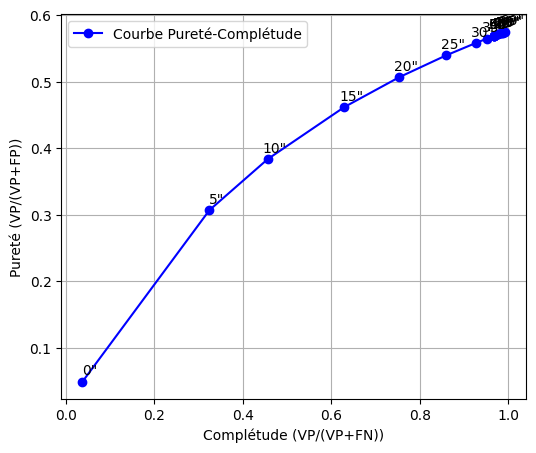

In [22]:
# Calcul des métriques pour différents rayons
rayons = np.arange(0, 91, 5)
resultats, paires = calcul_metriques_correlation(table_in_degrees_AMAS, gen_in_degrees_AMAS, rayons_corr_arcsec=rayons)

for rayon in sorted(resultats.keys()):
    print(f"Rayon {rayon}\": VP={resultats[rayon]['VP']} FP={resultats[rayon]['FP']} FN={resultats[rayon]['FN']} "
          f"Purete={resultats[rayon]['purete']:.2f} Completude={resultats[rayon]['completude']:.2f}")

plot_purete_completude(resultats)

In [ ]:
def calcul_metriques_correlation(table_input, table_output, rayons_corr_arcsec=np.arange(1, 91, 5), 
                               table_cols={'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Args:
        table_input (np.ndarray): Catalogue d'entrée (avec colonnes num_window, RA, DEC).
        table_output (np.ndarray): Catalogue de sortie (mêmes colonnes que table_input).
        rayons_corr_arcsec (array-like): Liste des rayons de corrélation à tester (en arcsecondes).
        table_cols (dict): Dictionnaire mappant les noms de colonnes aux indices dans les tableaux.

    Returns:
        dict: Dictionnaire des métriques pour chaque rayon de corrélation, sous la forme:
            {
                rayon: {
                    'VP': int,       # vrais positifs
                    'FP': int,       # faux positifs
                    'FN': int,       # faux négatifs
                    'purete': float, # pureté (VP / (VP + FP))
                    'completude': float # complétude (VP / (VP + FN))
                },
                ...
            }
    """

    resultats = {rayon: {'VP': 0, 'FP': 0, 'FN': 0} for rayon in rayons_corr_arcsec}
    
    fenetres = np.unique(table_input[:, table_cols['num_window']])
    centre_fictif = SkyCoord(ra=180 * u.deg, dec=0 * u.deg, frame='icrs')
    offset_frame = SkyOffsetFrame(origin=centre_fictif)
    
    for fen in fenetres:
        # Sélection des sources dans la même fenêtre
        input_fen = table_input[table_input[:, table_cols['num_window']] == fen]
        output_fen = table_output[table_output[:, table_cols['num_window']] == fen]
        
        if len(input_fen) == 0 or len(output_fen) == 0:
            continue
        
        # Conversion des coordonnées pour la fenêtre courante
        ra_input_rel = input_fen[:, table_cols['RA']] * u.deg
        dec_input_rel = input_fen[:, table_cols['DEC']] * u.deg
        coords_input_proj = SkyCoord(lon=ra_input_rel, lat=dec_input_rel, frame=offset_frame).transform_to('icrs')
        
        ra_output_rel = output_fen[:, table_cols['RA']] * u.deg
        dec_output_rel = output_fen[:, table_cols['DEC']] * u.deg
        coords_output_proj = SkyCoord(lon=ra_output_rel, lat=dec_output_rel, frame=offset_frame).transform_to('icrs')
        
        # Pour chaque rayon de corrélation
        for rayon in rayons_corr_arcsec:
            rayon_deg = rayon / 3600
            vp_fen = 0
            input_matched = np.zeros(len(coords_input_proj), dtype=bool)
            output_matched = np.zeros(len(coords_output_proj), dtype=bool)
            
            # Recherche des correspondances
            for i, coord_in in enumerate(coords_input_proj):
                sep = coord_in.separation(coords_output_proj)
                min_sep_idx = np.argmin(sep)
                min_sep = sep[min_sep_idx].degree
                
                if min_sep <= rayon_deg:
                    vp_fen += 1
                    input_matched[i] = True
                    output_matched[min_sep_idx] = True
            
            # Mise à jour des compteurs globaux
            resultats[rayon]['VP'] += vp_fen
            resultats[rayon]['FN'] += (len(coords_input_proj) - np.sum(input_matched))
            resultats[rayon]['FP'] += (len(coords_output_proj) - np.sum(output_matched))
    
    # Calcul des métriques finales (pureté et complétude)
    for rayon in resultats:
        VP = resultats[rayon]['VP']
        FP = resultats[rayon]['FP']
        FN = resultats[rayon]['FN']
        
        resultats[rayon]['purete'] = VP / (VP + FP) if (VP + FP) > 0 else 0.0
        resultats[rayon]['completude'] = VP / (VP + FN) if (VP + FN) > 0 else 0.0
    
    return resultats


def plot_purete_completude(resultats, figsize=(6, 5)):
    """
    Args:
        resultats (dict): Dictionnaire retourné par calcul_metriques_correlation contenant les métriques.
        figsize (tuple, optional): Taille de la figure matplotlib (par défaut (6, 5)).

    Returns:
        None: Affiche un graphique pureté vs complétude annoté par rayon de corrélation.
    """

    rayons = sorted(resultats.keys())
    puretes = [resultats[r]['purete'] for r in rayons]
    completudes = [resultats[r]['completude'] for r in rayons]
    
    plt.figure(figsize=figsize)
    plt.plot(completudes, puretes, 'bo-', linewidth=2, markersize=8, label='Courbe Pureté-Complétude')
    
    # Annotation des points avec les rayons
    for r, p, c in zip(rayons, puretes, completudes):
        plt.annotate(f'{r}"', (c, p), textcoords="offset points", 
                    xytext=(5,5), ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='gray', alpha=0.3))
    
    #plt.xscale('log')
    #plt.yscale('log')
    plt.xlabel('Complétude (VP/(VP+FN))', fontsize=12)
    plt.ylabel('Pureté (VP/(VP+FP))', fontsize=12)
    plt.title('Pureté - Complétude par rayon de corrélation', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

Rayon 1": VP=5942 FP=20589 FN=18115 Purete=0.22 Completude=0.25
Rayon 2": VP=14776 FP=17336 FN=9281 Purete=0.46 Completude=0.61
Rayon 3": VP=19496 FP=15461 FN=4561 Purete=0.56 Completude=0.81
Rayon 4": VP=20898 FP=14811 FN=3159 Purete=0.59 Completude=0.87
Rayon 5": VP=21389 FP=14610 FN=2668 Purete=0.59 Completude=0.89
Rayon 6": VP=21615 FP=14527 FN=2442 Purete=0.60 Completude=0.90
Rayon 7": VP=21766 FP=14445 FN=2291 Purete=0.60 Completude=0.90
Rayon 8": VP=21810 FP=14418 FN=2247 Purete=0.60 Completude=0.91
Rayon 9": VP=21811 FP=14418 FN=2246 Purete=0.60 Completude=0.91
Rayon 10": VP=21813 FP=14418 FN=2244 Purete=0.60 Completude=0.91
Rayon 11": VP=21814 FP=14418 FN=2243 Purete=0.60 Completude=0.91
Rayon 12": VP=21814 FP=14418 FN=2243 Purete=0.60 Completude=0.91
Rayon 13": VP=21814 FP=14418 FN=2243 Purete=0.60 Completude=0.91
Rayon 14": VP=21814 FP=14418 FN=2243 Purete=0.60 Completude=0.91


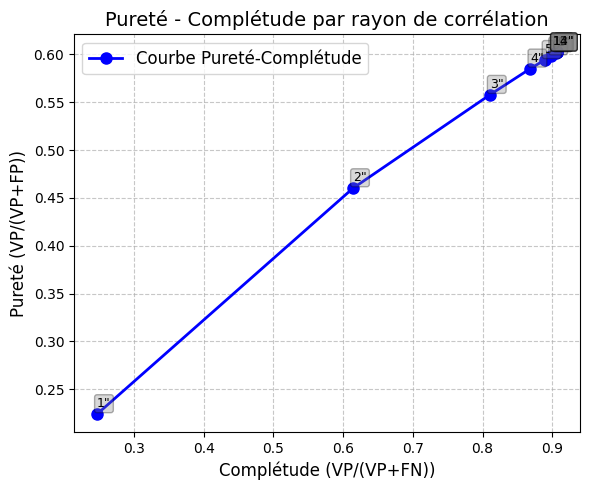

In [24]:
# Calcul des métriques pour différents rayons
rayons = np.arange(1, 15, 1)
resultats = calcul_metriques_correlation(table_in_degrees_AGN, gen_in_degrees_AGN, rayons_corr_arcsec=rayons)

for rayon in sorted(resultats.keys()):
    print(f"Rayon {rayon}\": VP={resultats[rayon]['VP']} FP={resultats[rayon]['FP']} FN={resultats[rayon]['FN']} "
          f"Purete={resultats[rayon]['purete']:.2f} Completude={resultats[rayon]['completude']:.2f}")

plot_purete_completude(resultats)

In [ ]:
def plot_window_comparison(table_input_AGN, table_output_AGN, 
                          table_input_AMAS, table_output_AMAS, 
                          numero_de_fenetre, 
                          window_size_arcmin=3,
                          table_cols={'num_window': 0, 'RA': 1, 'DEC': 2}):
    """
    Trace une comparaison des positions RA/DEC entre catalogues d'entrée et de sortie 
    pour AGN et AMAS dans une fenêtre spécifique.

    Args:
        table_input_AGN (np.ndarray): Catalogue AGN de référence, avec colonnes selon table_cols.
        table_output_AGN (np.ndarray): Catalogue AGN prédit, même format que table_input_AGN.
        table_input_AMAS (np.ndarray): Catalogue AMAS de référence, même format.
        table_output_AMAS (np.ndarray): Catalogue AMAS prédit, même format.
        numero_de_fenetre (int): Numéro de la fenêtre à visualiser.
        window_size_arcmin (float, optional): Taille de la fenêtre en minutes d'arc. Défaut à 3.
        table_cols (dict, optional): Dictionnaire des colonnes {'num_window': idx, 'RA': idx, 'DEC': idx}.

    Returns:
        None: Affiche un graphique matplotlib montrant les positions des sources par catalogue
              dans la fenêtre spécifiée, avec légende, limites et annotations.
    """
    # Extraire les données pour la fenêtre spécifiée
    input_AGN = table_input_AGN[table_input_AGN[:, table_cols['num_window']] == numero_de_fenetre]
    output_AGN = table_output_AGN[table_output_AGN[:, table_cols['num_window']] == numero_de_fenetre]
    input_AMAS = table_input_AMAS[table_input_AMAS[:, table_cols['num_window']] == numero_de_fenetre]
    output_AMAS = table_output_AMAS[table_output_AMAS[:, table_cols['num_window']] == numero_de_fenetre]
    
    # Vérifier si la fenêtre existe dans au moins un catalogue
    if len(input_AGN) == 0 and len(output_AGN) == 0 and len(input_AMAS) == 0 and len(output_AMAS) == 0:
        print(f"Aucune donnée trouvée pour la fenêtre {numero_de_fenetre}")
        return
    
    # Création du plot
    plt.figure(figsize=(5.5, 4))
    
    # Tracer les points d'entrée AGN (bleu étoiles)
    if len(input_AGN) > 0:
        plt.scatter(input_AGN[:, table_cols['RA']], 
                   input_AGN[:, table_cols['DEC']], 
                   c='blue', s=100, marker='*', label='Input AGN', alpha=0.8, 
                   edgecolors='w', linewidth=0.5)
    
    # Tracer les points de sortie AGN (rouge étoiles)
    if len(output_AGN) > 0:
        plt.scatter(output_AGN[:, table_cols['RA']], 
                   output_AGN[:, table_cols['DEC']], 
                   c='red', s=100, marker='*', label='Output AGN', alpha=0.8, 
                   edgecolors='w', linewidth=0.5)
    
    # Tracer les points d'entrée AMAS (bleu carrés)
    if len(input_AMAS) > 0:
        plt.scatter(input_AMAS[:, table_cols['RA']], 
                   input_AMAS[:, table_cols['DEC']], 
                   c='blue', s=100, marker='s', label='Input AMAS', alpha=0.8, 
                   edgecolors='w', linewidth=0.5)
    
    # Tracer les points de sortie AMAS (rouge carrés)
    if len(output_AMAS) > 0:
        plt.scatter(output_AMAS[:, table_cols['RA']], 
                   output_AMAS[:, table_cols['DEC']], 
                   c='red', s=100, marker='s', label='Output AMAS', alpha=0.8, 
                   edgecolors='w', linewidth=0.5)
    
    # Ajouter les lignes de délimitation de la fenêtre
    window_size_deg = window_size_arcmin / 60
    plt.axhline(-window_size_deg/2, color='gray', linestyle='--')
    plt.axhline(window_size_deg/2, color='gray', linestyle='--')
    plt.axvline(-window_size_deg/2, color='gray', linestyle='--')
    plt.axvline(window_size_deg/2, color='gray', linestyle='--')
    
    # Configuration des axes
    axis_limit = window_size_deg / 1.5
    plt.xlim(-axis_limit, axis_limit)
    plt.ylim(-axis_limit, axis_limit)
    plt.xlabel('Ascension droite (deg)', fontsize=12)
    plt.ylabel('Declination (deg)', fontsize=12)
    plt.title(f'Fenestron {numero_de_fenetre}', pad=20)
    
    # Ajouter la légende si au moins un catalogue a des points
    if len(input_AGN) > 0 or len(output_AGN) > 0 or len(input_AMAS) > 0 or len(output_AMAS) > 0:
        plt.legend(fontsize=10, framealpha=0.3, 
                  bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Ajout d'un texte d'information
    info_text = (f"Input AGN: {len(input_AGN)}  Output AGN: {len(output_AGN)}\n"
                 f"Input AMAS: {len(input_AMAS)}  Output AMAS: {len(output_AMAS)}")
    plt.annotate(info_text, xy=(0.5, 0.02), xycoords='axes fraction',
                ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.show()

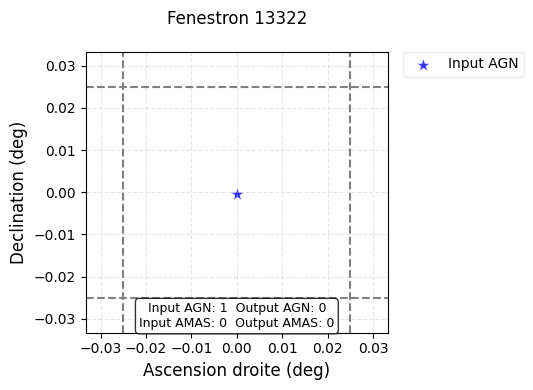

In [556]:
numero_fenestron = random.randint(0, 20000)

plot_window_comparison(table_in_degrees_AGN, gen_in_degrees_AGN,
                      table_in_degrees_AMAS, gen_in_degrees_AMAS,
                      numero_de_fenetre=numero_fenestron)

In [438]:
table_AGN

array([[    0,   504,   514],
       [    0,   678,   610],
       [    1,   508,   514],
       ...,
       [23866,   520,   505],
       [23867,   520,   506],
       [23867,   280,   756]])

In [443]:
gen_AGN[:,0]

array([    0,     0,     1, ...,  9999, 10000, 10000])